## Project - Protein Structure Feature Engineering Pipeline for Generative Deep Learning

#### Design a feature extraction, encoding, and decoding framework that converts a protein structure (PDB) into a machine-learning-friendly representation while preserving structural, physiochemical, and spatial information required for downstream generative AI applications.

In [6]:
pip install biopython numpy pandas scipy scikit-learn network matplotlib

Note: you may need to restart the kernel to use updated packages.


In [170]:
from Bio.PDB import PDBParser
import pandas as pd

parser = PDBParser(QUIET=True)
structure = parser.get_structure("protein", "7rfw.pdb")

features = []

for model in structure:
    for chain in model:
        for residue in chain:
            if 'CA' in residue:
                ca = residue['CA']
                features.append({
                    "residue": residue.get_resname(),
                    "x": ca.coord[0],
                    "y": ca.coord[1],
                    "z": ca.coord[2]
                })

df = pd.DataFrame(features)

print(df.head())

  residue      x      y       z
0     SER -2.390  6.469 -16.320
1     GLY -2.338  7.105 -12.557
2     PHE  0.436  7.048  -9.969
3     ARG  0.097  5.596  -6.466
4     LYS  2.366  4.416  -3.609


## Physicochemical Mapping

In [172]:
hydrophobicity = {
    'ALA': 1.8,
    'ARG': -4.5,
    'ASN': -3.5,
    'ASP': -3.5,
    'CYS': 2.5,
    'GLN': -3.5,
    'GLU': -3.5,
    'GLY': -0.4,
    'HIS': -3.2,
    'ILE': 4.5,
    'LEU': 3.8,
    'LYS': -3.9,
    'MET': 1.9,
    'PHE': 2.8,
    'PRO': -1.6,
    'SER': -0.8,
    'THR': -0.7,
    'TRP': -0.9,
    'TYR': -1.3,
    'VAL': 4.2
}

In [174]:
df["hydrophobicity"] = df["residue"].map(hydrophobicity)
print(df.head())

  residue      x      y       z  hydrophobicity
0     SER -2.390  6.469 -16.320            -0.8
1     GLY -2.338  7.105 -12.557            -0.4
2     PHE  0.436  7.048  -9.969             2.8
3     ARG  0.097  5.596  -6.466            -4.5
4     LYS  2.366  4.416  -3.609            -3.9


In [176]:
charge = {
    'ASP': -1,
    'GLU': -1,
    'LYS': 1,
    'ARG': 1,
    'HIS': 1
}

df['charge'] = df['residue'].map(charge).fillna(0)
print(df[['residue','charge']].head(20))

   residue  charge
0      SER     0.0
1      GLY     0.0
2      PHE     0.0
3      ARG     1.0
4      LYS     1.0
5      MET     0.0
6      ALA     0.0
7      PHE     0.0
8      PRO     0.0
9      SER     0.0
10     GLY     0.0
11     LYS     1.0
12     VAL     0.0
13     GLU    -1.0
14     GLY     0.0
15     CYS     0.0
16     MET     0.0
17     VAL     0.0
18     GLN     0.0
19     VAL     0.0


In [178]:
print(df['charge'].value_counts())

charge
 0.0    251
 1.0     29
-1.0     26
Name: count, dtype: int64


## Graph Construction

In [181]:
from scipy.spatial.distance import cdist

coords = df[['x', 'y', 'z']].values
dist_matrix = cdist(coords, coords)
adjacency = (dist_matrix < 8).astype(int)
np.fill_diagonal(adjacency, 0)

In [183]:
print("Distance Matrix Shape:", dist_matrix.shape)

Distance Matrix Shape: (306, 306)


In [185]:
dist_df = pd.DataFrame(dist_matrix)

display(dist_df.head(10))

,0,1,2,3,4,5,6,7,8,9,...,296,297,298,299,300,301,302,303,304,305
0,0.000000,3.816722,6.975437,10.200422,13.726029,14.149192,17.683785,19.105529,20.490578,23.970016,...,13.179458,13.304560,9.945874,8.295329,10.928339,11.346613,14.944100,17.137707,20.609051,23.761755
1,3.816722,0.000000,3.794215,6.731017,10.460643,11.455382,15.174204,17.208751,18.787950,21.974866,...,13.248239,13.080513,9.356641,9.009023,12.186978,12.093570,15.291009,17.237080,20.308677,23.539089
2,6.975437,3.794215,0.000000,3.807129,7.148561,8.732789,12.519359,14.889642,17.050319,19.987693,...,11.358200,11.203978,7.650354,8.332493,11.824481,11.789168,14.288266,16.352879,19.045413,22.484608
3,10.200422,6.731017,3.807129,0.000000,3.834477,5.819479,9.547471,12.485395,14.595672,17.128249,...,12.905159,11.909615,8.604025,10.672868,13.666837,12.783096,14.663658,16.045528,18.119127,21.374753
4,13.726029,10.460643,7.148561,3.834477,0.000000,3.803545,6.843730,10.246163,12.851569,14.826637,...,13.156977,11.823179,9.414283,12.308683,14.887931,13.817343,14.739011,15.816101,17.173243,20.379806
5,14.149192,11.455382,8.732789,5.819479,3.803545,0.000000,3.802744,6.753127,9.186927,11.553767,...,12.655169,10.279770,8.223212,11.753790,13.443883,11.584293,12.068968,12.513554,13.609748,16.675175
6,17.683785,15.174204,12.519359,9.547471,6.843730,3.802744,0.000000,3.825630,6.471057,8.122482,...,14.555697,11.694335,10.683157,14.465226,15.427145,13.179408,12.652300,12.230388,12.211644,14.848149
7,19.105529,17.208751,14.889642,12.485395,10.246163,6.753127,3.825630,0.000000,3.820944,6.061173,...,14.572530,11.153780,11.092326,14.850373,14.826591,12.215844,10.793153,9.575536,8.752291,11.189007
8,20.490578,18.787950,17.050319,14.595672,12.851569,9.186927,6.471057,3.820944,0.000000,3.826672,...,17.491382,13.811597,13.488901,17.070872,16.634702,13.419787,12.152482,9.814684,8.410652,9.698717
9,23.970016,21.974866,19.987693,17.128249,14.826637,11.553767,8.122482,6.061173,3.826672,0.000000,...,20.554433,17.002914,16.880040,20.571251,20.243124,17.156076,15.616713,13.203723,11.064084,11.529200


In [187]:
print("Adjacency Matrix Shape:", adjacency.shape)

print(adjacency[:10, :10])

Adjacency Matrix Shape: (306, 306)
[[0 1 1 0 0 0 0 0 0 0]
 [1 0 1 1 0 0 0 0 0 0]
 [1 1 0 1 1 0 0 0 0 0]
 [0 1 1 0 1 1 0 0 0 0]
 [0 0 1 1 0 1 1 0 0 0]
 [0 0 0 1 1 0 1 1 0 0]
 [0 0 0 0 1 1 0 1 1 0]
 [0 0 0 0 0 1 1 0 1 1]
 [0 0 0 0 0 0 1 1 0 1]
 [0 0 0 0 0 0 0 1 1 0]]


## Encoder Design

In [190]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

residue_encoded = encoder.fit_transform(
    df[['residue']]
).toarray()

In [192]:
from sklearn.preprocessing import StandardScaler

original_coords = df[['x', 'y', 'z']]
scaler = StandardScaler()

coord_encoded = scaler.fit_transform(original_coords)

In [194]:
node_features = np.concatenate(
    [
        residue_encoded,
        coord_encoded,
        df[['hydrophobicity']].values,
        df[['charge']].values
    ],

    axis = 1
)

In [196]:
{
    "node_features": node_features,
    "adjacency": adjacency
}

{'node_features': array([[ 0.        ,  0.        ,  0.        , ..., -1.46832526,
         -0.8       ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ..., -1.20424533,
         -0.4       ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ..., -1.02262449,
          2.8       ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ..., -1.19519234,
         -0.7       ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ..., -1.01862431,
          2.8       ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ..., -0.9897812 ,
         -3.5       ,  0.        ]]),
 'adjacency': array([[0, 1, 1, ..., 0, 0, 0],
        [1, 0, 1, ..., 0, 0, 0],
        [1, 1, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 1, 1],
        [0, 0, 0, ..., 1, 0, 1],
        [0, 0, 0, ..., 1, 1, 0]])}

## Decoder Design

In [199]:
decoded_residues = encoder.inverse_transform(
    node_features[:,:20]
)

In [201]:
decoded_coords = scaler.inverse_transform(coord_encoded)

In [203]:
reconstructed_adj = adjacency

## Validation

In [206]:
mse = np.mean(
    (original_coords - decoded_coords)**2
)
print("Reconstruction MSE:", mse)

Reconstruction MSE: 4.9985772e-14


## Visualization

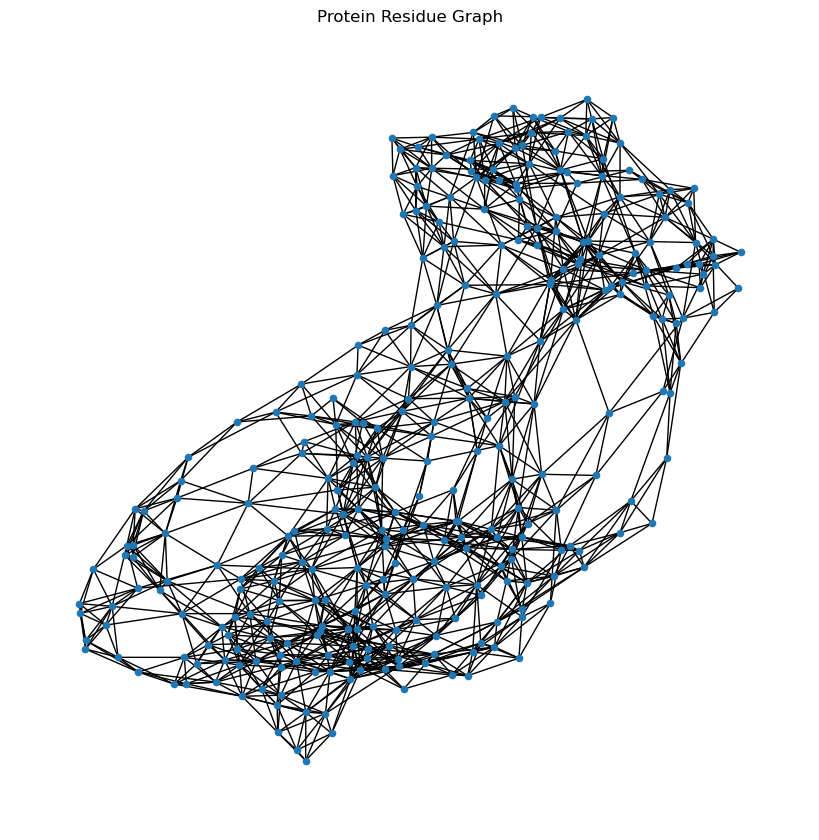

In [154]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_numpy_array(adjacency)

plt.figure(figsize=(8,8))
nx.draw(
    G,
    node_size=20,
    with_labels=False
)

plt.title("Protein Residue Graph")
plt.show()

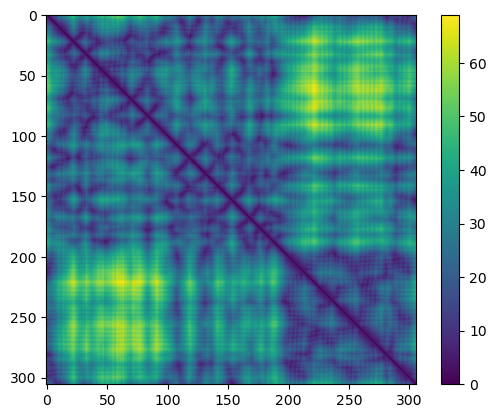

In [140]:
plt.imshow(dist_matrix)
plt.colorbar()

In [209]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print("Number of Residues:", num_nodes)
print("Number of Connections:", num_edges)

Number of Residues: 306
Number of Connections: 1460
